In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

path = "/content/drive/MyDrive/Dataset-3"
print("Exists:", os.path.exists(path))
print("Is folder:", os.path.isdir(path))

Exists: True
Is folder: True


In [ ]:
print(os.listdir("/content/drive/MyDrive/Dataset-3"))

['Non-liquid', 'Liquid']


In [ ]:
data_dir = "/content/drive/MyDrive/Dataset-3"

In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

full_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=42
)

class_names = full_ds.class_names
print("Classes:", class_names)

Found 1007 files belonging to 2 classes.
Classes: ['Liquid', 'Non-liquid']


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),

    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
import os

for root, _, files in os.walk(data_dir):
    for f in files:
        path = os.path.join(root, f)
        if os.path.getsize(path) == 0:
            print("EMPTY FILE:", path)

In [ ]:
import os

bad_file = "/content/drive/MyDrive/Dataset-3/Liquid/WhatsApp Image 2026-02-27 at 4.26.46 4PM.jpeg"

if os.path.exists(bad_file):
    os.remove(bad_file)
    print("Deleted empty file")
else:
    print("File not found")

File not found


In [ ]:
import os

for root, _, files in os.walk(data_dir):
    for f in files:
        path = os.path.join(root, f)
        if os.path.getsize(path) == 0:
            print("EMPTY FILE STILL EXISTS:", path)

In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=42
)

Found 1007 files belonging to 2 classes.


In [ ]:
total_batches = tf.data.experimental.cardinality(dataset).numpy()

train_size = int(0.8 * total_batches)

train_ds = dataset.take(train_size)
test_ds = dataset.skip(train_size)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [ ]:
history = model.fit(
    train_ds,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 118s 49ms/step - accuracy: 0.8062 - loss: 0.4402
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8975 - loss: 0.2485
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9150 - loss: 0.2153
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9450 - loss: 0.1621
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9463 - loss: 0.1476
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9488 - loss: 0.1444
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9600 - loss: 0.1195
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9563 - loss: 0.1120
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9712 - loss: 0.1074
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9750 - loss: 0.0854


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print(" Final Test Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.9469 - loss: 0.1620
 Final Test Accuracy: 0.9468598961830139


In [ ]:
model.save("liquid.h5")   # HDF5 format

In [ ]:
model.save("final_adjusted_liquid_again.h5")

In [ ]:
#confusion matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Collect true labels and predictions from test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend((preds.squeeze() > 0.5).astype(int))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

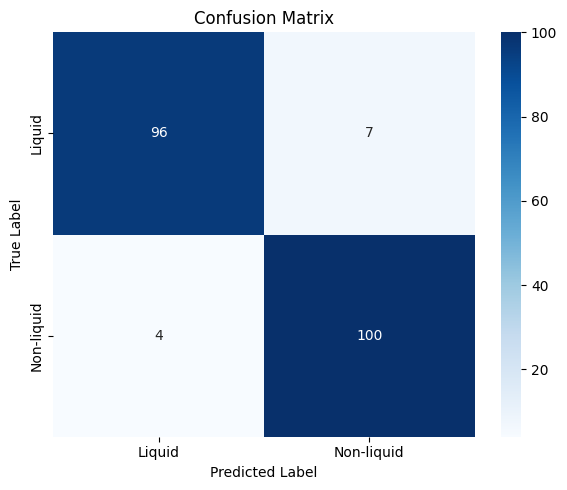

In [ ]:
# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_names = ['Liquid', 'Non-liquid']

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Print detailed classification report
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      Liquid       0.96      0.93      0.95       103
  Non-liquid       0.93      0.96      0.95       104

    accuracy                           0.95       207
   macro avg       0.95      0.95      0.95       207
weighted avg       0.95      0.95      0.95       207

